In [1]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/apple_dataset"

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive')

['IB_NIMCET-2024_V1 (1)-22.pdf',
 'pic.pdf',
 'iLovePDF',
 'Colab Notebooks',
 'Indigenous Dataset for Apple Leaf Disease Detection and Classification']

In [3]:
import os
dataset_path="/content/drive/MyDrive/Indigenous Dataset for Apple Leaf Disease Detection and Classification"
print(os.listdir(dataset_path))

['Indigenous Dataset for Apple Leaf Disease Detection and Classification']


In [4]:
import os

for folder in os.listdir(dataset_path):
    print(folder, "->", len(os.listdir(os.path.join(dataset_path, folder))))

Indigenous Dataset for Apple Leaf Disease Detection and Classification -> 2


In [5]:
!cp -r "/content/drive/MyDrive/Indigenous Dataset for Apple Leaf Disease Detection and Classification" /content/

In [16]:
!mv "/content/Indigenous Dataset for Apple Leaf Disease Detection and Classification/Indigenous Dataset for Apple Leaf Disease Detection and Classification" /content/apple_dataset

In [17]:
train_path = "/content/apple_dataset/Train_Set"
test_path = "/content/apple_dataset/Test_Set"

In [18]:
import os

def count_images(folder):
    total = 0
    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)
        num = len(os.listdir(class_path))
        print(f"{cls}: {num}")
        total += num
    print("Total:", total)

count_images(train_path)

Apple_Mosaic: 1908
Healthy: 1828
Alternaria: 1892
Total: 5628


In [20]:
from PIL import Image
import os

def clean_dataset(folder):
    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
            except:
                os.remove(img_path)
                print("Removed:", img_path)

clean_dataset(train_path)

In [21]:

clean_dataset(test_path)

🚀 STEP 1: Create Train + Val Split Manually

In [23]:
import os
import shutil
import random

source = "/content/apple_dataset/Train_Set"
dest = "/content/dataset"

train_dir = os.path.join(dest, "train")
val_dir = os.path.join(dest, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

split_ratio = 0.8  # 80% train, 20% val

for cls in os.listdir(source):
    cls_path = os.path.join(source, cls)

    images = os.listdir(cls_path)
    random.shuffle(images)

    split_index = int(len(images) * split_ratio)

    train_imgs = images[:split_index]
    val_imgs = images[split_index:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))

print("✅ Train/Val split done")

✅ Train/Val split done


STEP 2: Copy Test Set

In [24]:
shutil.copytree(
    "/content/apple_dataset/Test_Set",
    "/content/dataset/test",
    dirs_exist_ok=True
)

print("✅ Test set ready")

✅ Test set ready


STEP 3: Verify Structure

In [25]:
!ls /content/dataset

test  train  val


Now Cleaning Will Work

In [26]:
clean_dataset("/content/dataset/train")
clean_dataset("/content/dataset/val")
clean_dataset("/content/dataset/test")

Count Images (Now Correct)

In [49]:
count_images("/content/dataset/train")

Apple_Mosaic: 1526
Healthy: 1462
Alternaria: 1513
Total: 4501


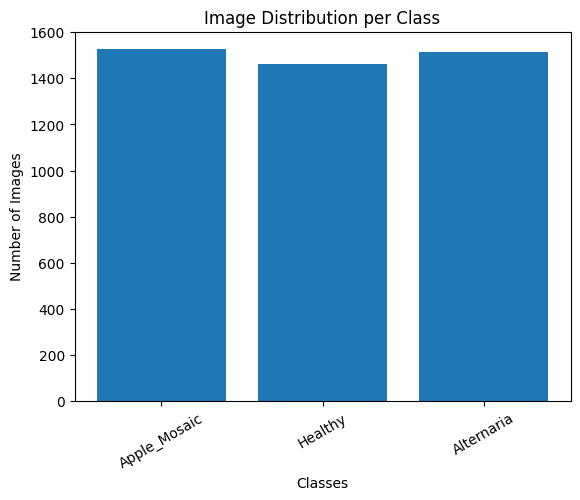

In [28]:
import os
import matplotlib.pyplot as plt

def plot_class_distribution(folder):
    classes = []
    counts = []

    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)
        num = len(os.listdir(class_path))

        classes.append(cls)
        counts.append(num)

    # Plot
    plt.figure()
    plt.bar(classes, counts)

    plt.title("Image Distribution per Class")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")

    plt.xticks(rotation=30)
    plt.show()

# Use it
plot_class_distribution("/content/dataset/train")

Count Apple Mosaic Images

In [29]:
mosaic_path = "/content/dataset/train/Apple_Mosaic"   # adjust if name slightly different

In [30]:
import os

num_images = len(os.listdir(mosaic_path))
print("Total Apple Mosaic images:", num_images)

Total Apple Mosaic images: 1526


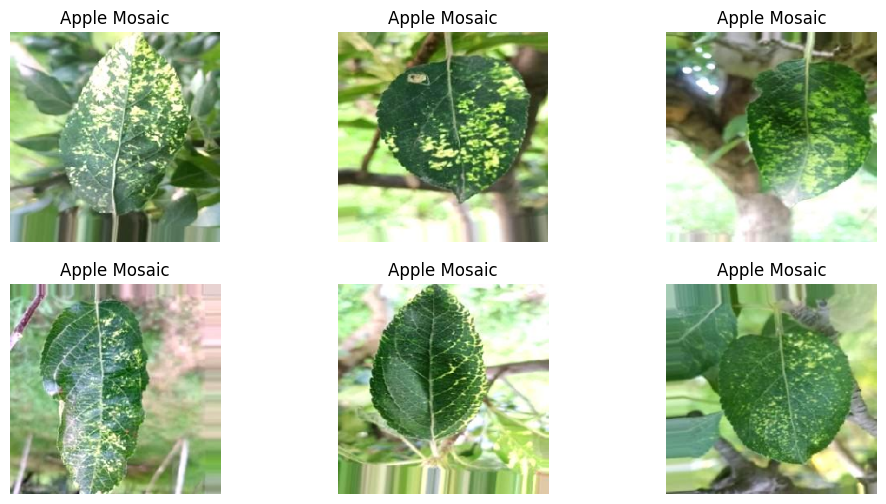

In [31]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import random
import os

def show_mosaic_images(folder, n=6):
    images = os.listdir(folder)
    sample = random.sample(images, min(n, len(images)))

    plt.figure(figsize=(12,6))

    for i, img_name in enumerate(sample):
        img_path = os.path.join(folder, img_name)
        img = load_img(img_path, target_size=(224,224))

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title("Apple Mosaic")
        plt.axis('off')

    plt.show()

show_mosaic_images(mosaic_path)

Count Images for ALL Classes

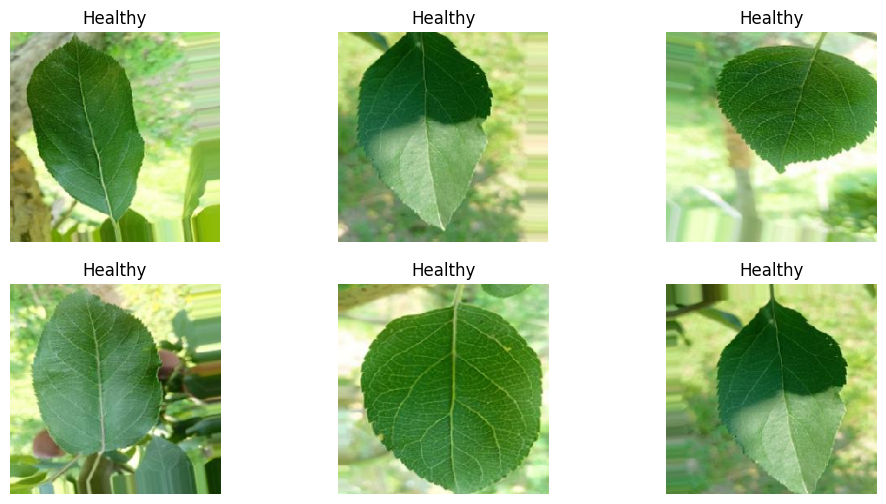

In [34]:
def show_images(folder, title):
    import matplotlib.pyplot as plt
    from tensorflow.keras.preprocessing.image import load_img
    import random, os

    images = os.listdir(folder)
    sample = random.sample(images, min(6, len(images)))

    plt.figure(figsize=(12,6))

    for i, img_name in enumerate(sample):
        img_path = os.path.join(folder, img_name)
        img = load_img(img_path, target_size=(224,224))

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')

    plt.show()

show_images("/content/dataset/train/Healthy", "Healthy")

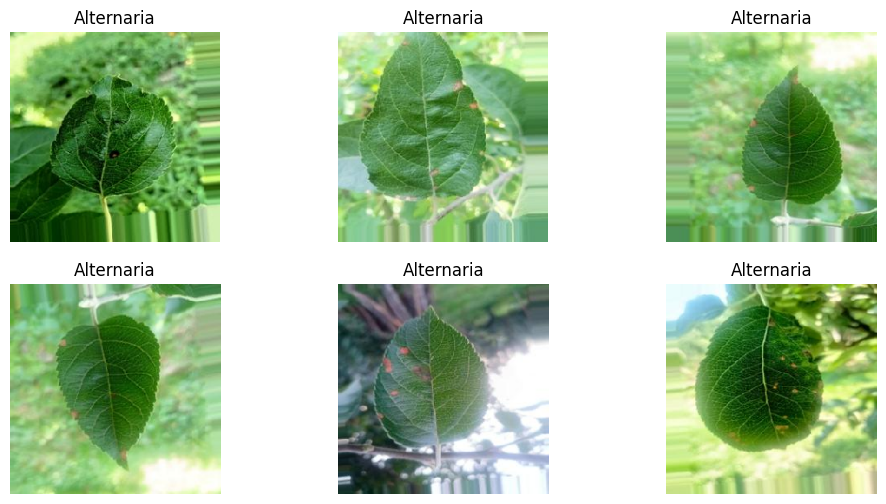

In [50]:
show_images("/content/dataset/train/Alternaria", "Alternaria")

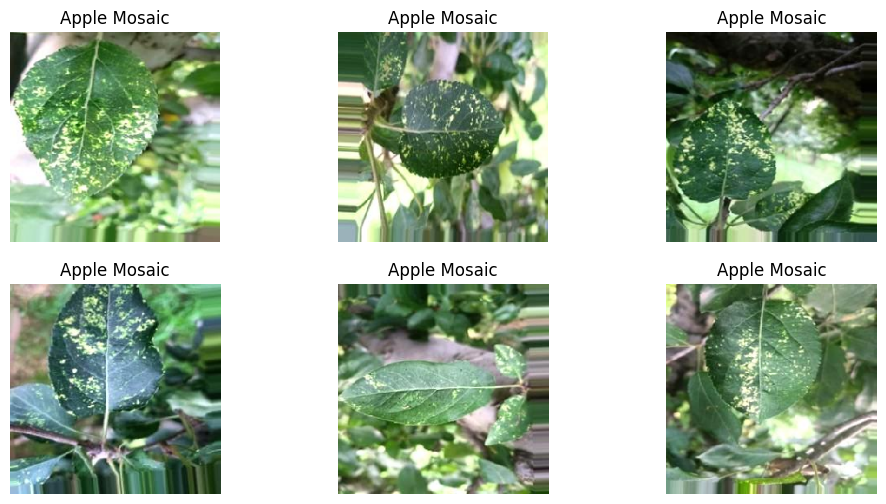

In [36]:
show_images("/content/dataset/train/Apple_Mosaic", "Apple Mosaic")

In [67]:
import tensorflow as tf

IMG_SIZE = 224 # Ensure consistency with MobileNetV2 input

# Define a preprocessing function to apply to images
def preprocess_data(image, label):
    # Resize images to the target size expected by the model
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Apply MobileNetV2 specific preprocessing (normalizes to [-1, 1])
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# Note: Augmentations from the original ImageDataGenerator are not included here for simplicity of error fixing.
# If augmentations are desired, they should be added as Keras preprocessing layers
# (e.g., RandomFlip, RandomRotation) within the model or as part of the tf.data pipeline.

Focus on Leaf (Remove Background Noise)

In [38]:
import cv2
import numpy as np

def enhance_image(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Increase contrast
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0)
    cl = clahe.apply(l)

    merged = cv2.merge((cl,a,b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return enhanced

Resize Properly (VERY IMPORTANT)

In [60]:
target_size=(224, 224)

In [76]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf

# Load training data in raw, unbatched format to easily collect labels for class weights
train_data_raw = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/train',
    labels='inferred',
    label_mode='categorical', # Labels are one-hot encoded
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation='nearest',
    batch_size=None, # Load unbatched to iterate over individual labels
    shuffle=False # Keep order for consistent label collection
)

# Collect labels for class weight calculation
all_labels = []
for _, label_one_hot in train_data_raw:
    all_labels.append(tf.argmax(label_one_hot).numpy()) # Convert one-hot to integer label

labels = np.array(all_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

# Now, create the batched and preprocessed train_data for model training
train_data = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation='nearest',
    batch_size=32,
    shuffle=True # Shuffle for training
)
train_data = train_data.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)

Found 4501 files belonging to 3 classes.
Found 4501 files belonging to 3 classes.


### Define Validation Data Generator

In [77]:
import tensorflow as tf

# Load validation data
val_data = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/val',
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation='nearest',
    batch_size=32,
    shuffle=False # No need to shuffle validation data
)
val_data = val_data.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)

Found 1127 files belonging to 3 classes.


### Define Test Data Generator

In [78]:
import tensorflow as tf

# Load test data
test_data = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/test',
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation='nearest',
    batch_size=32,
    shuffle=False # No need to shuffle test data
)
test_data = test_data.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)

Found 1893 files belonging to 3 classes.


. Build Model (MobileNetV2)

In [73]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import numpy as np # Import numpy

IMG_SIZE = 224  # MobileNet works best with 224

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Determine the number of classes from the labels generated for class_weights
# This assumes 'labels' variable from cell -EalzKPL7_cc is available in the kernel
num_classes = len(np.unique(labels))

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,591,811 (9.89 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [75]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [79]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.7852 - loss: 0.5522 - val_accuracy: 0.9485 - val_loss: 0.1800 - learning_rate: 1.0000e-04
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.9351 - loss: 0.1744 - val_accuracy: 0.9698 - val_loss: 0.0950 - learning_rate: 1.0000e-04
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.9562 - loss: 0.1197 - val_accuracy: 0.9760 - val_loss: 0.0645 - learning_rate: 1.0000e-04
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9696 - loss: 0.0829 - val_accuracy: 0.9796 - val_loss: 0.0486 - learning_rate: 1.0000e-04
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9853 - loss: 0.0573 - val_accuracy: 0.9831 - val_loss: 0.0409 - learning_rate: 1.0000e-04
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.9851 - loss: 0.0488 - val_accuracy: 0.9885 - val_loss: 0.0346 - learning_rate: 1.0000e-04
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - acc

In [84]:
loss, test_acc = model.evaluate(test_data)

print(f"Test Accuracy: {test_acc*100:.2f}%")

60/60 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9942 - loss: 0.0127
Test Accuracy: 99.42%


Plot Training Graphs (Accuracy + Loss)

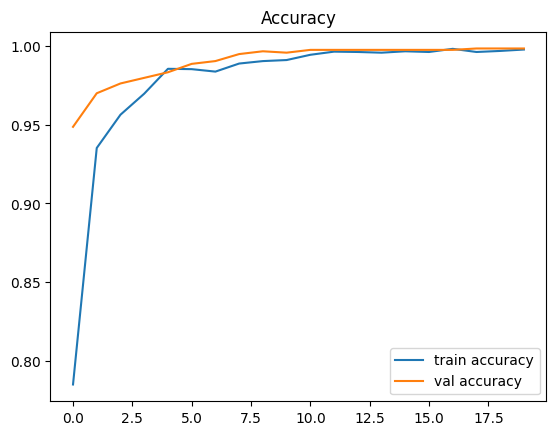

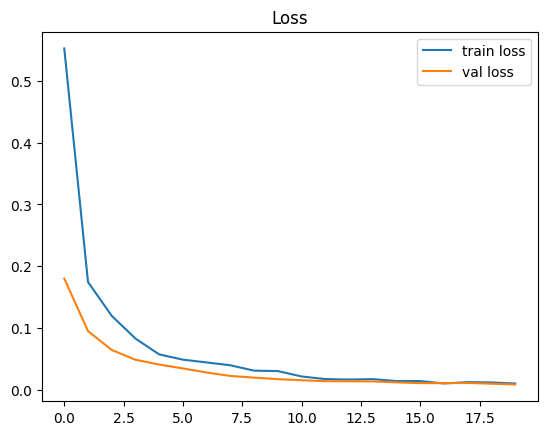

In [82]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

Confusion Matrix

In [92]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(val_data)
y_pred = np.argmax(y_pred, axis=1)

# To get y_true from a tf.data.Dataset, we need to iterate through it
y_true = []
for _, labels_one_hot in val_data:
    y_true.extend(np.argmax(labels_one_hot.numpy(), axis=1))
y_true = np.array(y_true)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

36/36 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step
Confusion Matrix:
[[377   0   2]
 [  0 382   0]
 [  0   0 366]]


Use Grad-CAM

Classification Report

In [93]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       379
           1       1.00      1.00      1.00       382
           2       0.99      1.00      1.00       366

    accuracy                           1.00      1127
   macro avg       1.00      1.00      1.00      1127
weighted avg       1.00      1.00      1.00      1127



Save Model

In [89]:
model.save("apple_leaf_model.h5")

Predict on New Image

In [95]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Get class names from the test set
class_names = os.listdir("/content/dataset/test")

# Pick a sample image from the first class found in the test set
# This ensures the image path exists
sample_class_path = os.path.join("/content/dataset/test", class_names[0])
img_path = os.path.join(sample_class_path, os.listdir(sample_class_path)[0])

print(f"Using image for prediction: {img_path}")

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

# Get class labels from the training data (assuming order is consistent)
# This is derived from the labels array used for class weights
class_labels = [label for label, _ in sorted(class_weights.items())]

# Map integer labels back to original string class names if available
# We infer the class names from the directory structure, matching the order returned by image_dataset_from_directory
import tensorflow as tf

# Re-create a small dummy dataset to get the class_names in the order TensorFlow uses
dummy_dataset = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    shuffle=False # Important to keep consistent order
)
actual_class_names = dummy_dataset.class_names

predicted_class_index = np.argmax(pred)
predicted_class_name = actual_class_names[predicted_class_index]

print(f"Prediction: {predicted_class_name} (Confidence: {np.max(pred)*100:.2f}%) ")

Using image for prediction: /content/dataset/test/Apple_Mosaic/lpu_rdp_m606.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Found 4501 files belonging to 3 classes.
Prediction: Alternaria (Confidence: 99.61%) 
